# Proyect 1: Image reduction

#### AST205 Benjamín Carrillo Carrasco

##### El objetivo principal del proyecto y el código es lograr la reducción de una imagen de ciencia mediante la calibración del CCD estándar.

##### Se tienen un total de 19 imagenes de tipo 'fit', una extensión que guarda información tanto de la observación (pixeles/ADUS) como también detalles técnicos. El primer paso en la reducción de datos es distinguir los 4 tipos de imágenes que se toman a modo de calibración antes de hacer la reducción.

##### -> BIAS: Es una imagen generada en base a la lectura del CCD sin estar observando nada, es decir, tiempo de exposición 0. Estas imagenes son necesarias ya que al momento de la lectura del CCD, el propio instrumento genera una "corriente base" que el sensor interpreta como electrones almacenados por los pozos de potencial presentes en las celdas de los píxeles, contaminando la imagen. Es necesario tener control de cuántos de estos píxeles generan 'read-out noise' para poder descartarlos de la imagen final.

##### -> DARK: Es una imagen tomada con tiempo de exposición, es decir, antes de leer el CCD se deja el telescopio "observando" con el detalle de que el obturador de la cámara está cerrado y por lo tanto no se captura luz. El objetivo es, una vez descartada la medición del BIAS, medir toda la 'dark current' generada por la temperatura adquirida del CCD durante el tiempo de exposición de la observación. Es un error de base que hay que tener en cuenta antes de la reducción.

##### -> FLAT: Es una imagen tomada apuntando a un objeto brillante (como el cielo en el amanecer) o el domo del telescopio iluminado, durante un tiempo de exposición corto. El objetivo es corregir la medición de ADUS en exceso o producto de la sensibilidad de cada píxel y eliminar la dependencia de la generación de ADUs con la ganancia y el tiempo de exposición. Además, permite tomar estas imágenes en distintos filtros que revelan sombras o manchas producidas por polvo en el lente, permitiendo corregir estos detalles.

##### -> LIGHT: Esta es la imagen en sí, el resultado de apuntar el telescopio al objeto de interés durante el tiempo de exposición que se estime conveniente. Es aquí donde debemos aplicar todas las calibraciones anteriores para corregir la imagen y reducirla.

##### En base a esto, el orden lógico de la reducción de datos viene de la siguiente manera:

<div align="center">
  <img src="WORKFLOW DIAGRAM.png" width="1000px">
  <p><i>Workflow diagram.</i></p>
</div>

##### A continuación, presento el código en el que trabajé para lograr una reducción de imagen de ciencia.

In [13]:
#Librerías necesarias
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

##### El primer paso es importar todas las librerías necesarias, que se fueron añadiendo a medida que el código se iba creando. En primera instancia, quiero explorar los comandos asociados a los archivos tipo '.fit'. Pero antes resulta conveniente ordenar los archivos según su tipo de imagen. Esto lo realizaré con un ciclo for donde a cada imagen de la carpeta de trabajo se le extrará su 'header', que es la parte del archivo 'fit' que contiene información sobre los detalles técnicos de la medición incluyendo el tipo de archivo.

In [14]:
with fits.open('LIGHT/image9.fit') as hdul:
    hdul.info()
    header = hdul[0].header
header
#acá estoy explorando las carpetas para encontrar las imagenes y extrar su header para confirmar que el proceso de ordenamiento fue exitoso.

Filename: LIGHT/image9.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      49   (4096, 4096)   int16 (rescales to uint16)   


SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 4096 / length of data axis 1                          
NAXIS2  =                 4096 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
OBSERVER= 'USM     '           / SBIGFITSEXT The name of the observer           
ORIGIN  = 'MAS500  '           / Description of location                        
TELESCOP= 'MAS500  '        

In [3]:
#Se mueve cada archivo a su carpeta, se utiliza el header de cada imagen para la clasificación

ruta = Path('.')

for archivo in ruta.glob('*.fits'): #se explora cada archivo de la carpeta donde está guardado el archivo .ipynb
    with fits.open(archivo) as hdul:
        image_type = hdul[0].header['IMAGETYP'] #se extrae el tipo de imagen leyendo el header de cada archivo
        if 'BIAS' in image_type:
            destino = 'BIAS'
        elif 'DARK' in image_type:
            destino = 'DARK'
        elif 'FLAT' in image_type:
            destino = 'FLAT'
        elif 'LIGHT' in image_type:
            destino = 'LIGHT'
        #se asigna una carpeta de destino según el tipo de imagen, y luego se crea la ruta de esa carpeta para  mover la ubicación del archivo
        carpeta_destino = ruta / destino
        carpeta_destino.mkdir(exist_ok=True)
        archivo.rename(carpeta_destino / archivo.name)

In [15]:
os.listdir("BIAS")
#con este comando reviso cuales archivos fueron clasificados como BIAS

['image1.fit',
 'image10.fit',
 'image12.fit',
 'image15.fit',
 'image16.fit',
 'image18.fit',
 'image4.fit',
 'image6.fit',
 'image7.fit']

##### Ya con las carpetas organizadas, toca trabajar con los tipos de imágenes que tenemos para la reducción:

## MASTER BIAS

##### La idea es explorar las imágenes BIAS, acá selecciono una de las BIAS al azar para explorar sus propiedades, como la intensidad mínima y máxima que se leyó, la desviación estándar de los datos recolectados, su media y obtener la imagen en sí:

In [16]:
image12 = "BIAS/image12.fit"
hdu_list = fits.open(image12)
data_image12 = hdu_list[0].data
print("Min:", np.min(data_image12))
print("Max:", np.max(data_image12))
print("Mean:", np.mean(data_image12))
print("Stdev:", np.std(data_image12))
#con este codigo extraigo informacion sobre los rangos para plotear la imagen

Min: 962
Max: 1342
Mean: 993.8608108758926
Stdev: 6.330050586249785


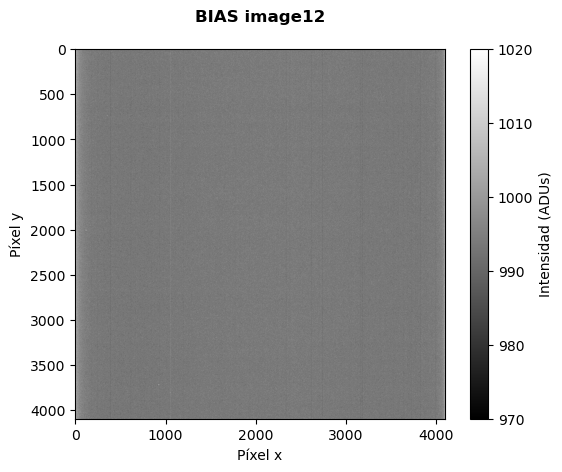

In [17]:
#Despliegue de la figura:

plt.imshow(data_image12, cmap="grey", vmin=970, vmax=1020)
plt.title("BIAS image12", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("Píxel x", fontsize=10)
plt.ylabel("Píxel y", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
cbar = plt.colorbar()
cbar.set_label("Intensidad (ADUs)", fontsize=10)
#chequeando la "estatica" del BIAS

##### Si vemos la distribución de la intensidad de estos píxeles nos damos cuenta de que siguen una distribución normal, donde la mayoría de ADUs poseen un valor aproximado de 994 (es el valor que se le asignó al píxel al momento de la lectura). En palabras simples, la distribución normal del 'read-out' noise nos dice aproximadamente cual es el valor de base que se tiene al momento de medir cada píxel, al momento de la medición real todos los píxeles generarán ADUs con estos valores más la intensidad aportada por los electrones liberados por la luz incidente.

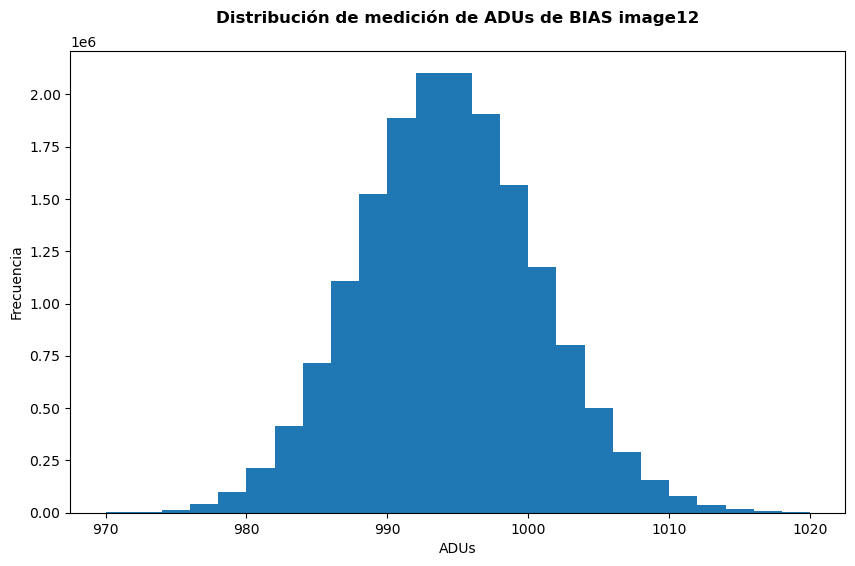

In [7]:
#Despliegue del histograma:

plt.figure(figsize=(10, 6))
histogram = plt.hist(data_image12.flatten(), bins=25, range = (970, 1020))
plt.title("Distribución de medición de ADUs de BIAS image12", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("ADUs", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.show()

#### Construcción del master BIAS

##### Para construir el master BIAS necesitamos combinar estadísticamente todas las imágenes de BIAS que se tienen. Mediante un ciclo 'for', se extraen los datos de cada imagen BIAS y se agrega a una lista, a la cual luego se le hace un "array" que consiste en pasar la matriz de datos a un vector. En el histograma se aprecia la distribución normal del Master BIAS. Para la construcción de la imagen se toma la mediana de los datos acumulados en la lista, y el rango en el que se muestra la imagen se selecciona tomando los percentiles donde se encuentran el 1% de los datos para el valor mínimo y el 99% de los datos para el valor máximo.

In [8]:
BIAS = "BIAS"
bias = os.listdir(BIAS) #definiendo la carpeta con los archivos BIAS
datos_bias = []

for archivo in bias: #se explora la carpeta
    ruta = BIAS + "/" + archivo #se crea la ruta del archivo
    with fits.open(ruta) as hdul:
        datos_bias.append(hdul[0].data) #se extrae la información del archivo y se agrega como elemento a una lista
#utilicé la IA Gemini para la idea de crear la variable "ruta" ya que me daba error al intentar escribir with fits.open(BIAS/archivo) as hdul

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
C:\Users\benja\AppData\Local\Temp\ipykernel_13276\696675120.py:19: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(Mean - Stdev, color='green', linestyle='--', linewidth=2, label=f'$\sigma = {Stdev:.2f}$')


Mínimo = 960
Máximo = 1885
Promedio = 993.8433245884048
Desviación estándar = 6.334083965555741


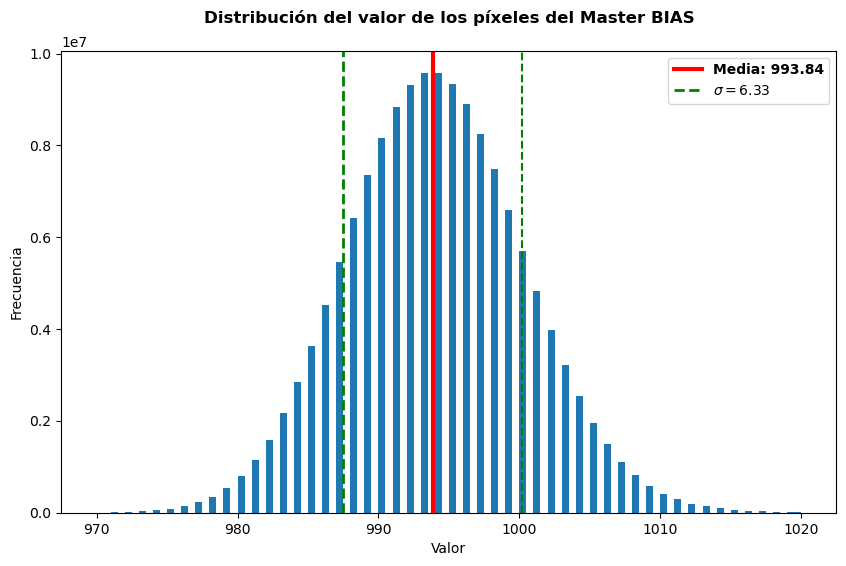

In [9]:
datos_bias_array = np.array(datos_bias) #Con este paso, que se repetirá en el resto de procesos pasamos un "cubo de imágenes" a una sola imagen. Se
                                        #transforma la matriz en un "vector" imagen que podemos graficar.
Min = np.min(datos_bias_array)
Max = np.max(datos_bias_array)
Mean = np.mean(datos_bias_array)
Stdev = np.std(datos_bias_array)
#Acá se extrae información importante sobre la distribución de ADUs en la imagen generada
print('Mínimo =', Min)
print('Máximo =', Max)
print('Promedio =', Mean)
print('Desviación estándar =', Stdev)

#Despliegue del histograma:

plt.figure(figsize=(10, 6))
histogram = plt.hist(datos_bias_array.flatten(), bins=100, range = (970, 1020)) #el histograma representa mucho mejor esta información

plt.axvline(Mean, color='red', linestyle='-', linewidth=3, label=f'Media: {Mean:.2f}')
plt.axvline(Mean - Stdev, color='green', linestyle='--', linewidth=2, label=f'$\sigma = {Stdev:.2f}$')
plt.axvline(Mean + Stdev, color='green', linestyle='--')
plt.title("Distribución del valor de los píxeles del Master BIAS", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("Valor", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=12, prop={'weight':'bold'})
plt.show()
#acá hice un histograma con los datos de la lista de listas, donde están contenidos todos los datos de los BIAS. La variable datos_bias_array
#es necesaria para construir un arreglo tridimensional de las imágenes

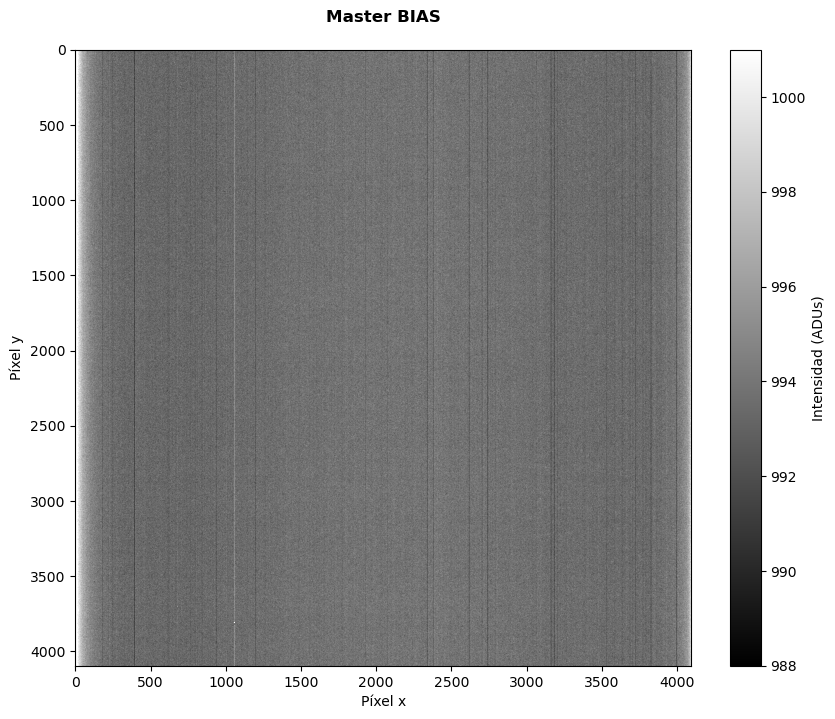

In [10]:
master_bias = np.median(datos_bias_array, axis=0) #Para combinar imágenes siempre usaremos la mediana, ya que este dato representa mucho mejor la
                                                  #distribución de los datos, mientras que el promedio agrega a la medición todos aquellos datos
                                                  #extremos que podrían no ser significativos para la reducción
vmin = np.percentile(master_bias, 1)
vmax = np.percentile(master_bias, 99)#El uso de 'np.percentile' entrega un rango más adecuado para visualizar la imagen

#Despliegue de la imagen del Master BIAS:

plt.figure(figsize=(10, 8))
plt.imshow(master_bias, cmap="grey", vmin = vmin, vmax = vmax)
plt.title("Master BIAS", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("Píxel x", fontsize=10)
plt.ylabel("Píxel y", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
cbar = plt.colorbar()
cbar.set_label("Intensidad (ADUs)", fontsize=10)
#acá saqué el promedio de las imagenes tridimensionales y con eso construí el master BIAS y plotee la imagen.

In [11]:
#ahora intentaré repetir el proceso para todos los tipos de imágenes

## MASTER DARK

##### EL procedimiento es similar a la construcción del Master BIAS, pero esta vez se trabaja con las imágenes tipo "Dark". Se sigue el procedimiento mostrado en el workflow, cada 'dark_frame' se construye quitando la "estática" del BIAS para extraer únicamente la "dark current" y se normaliza por el tiempo de exposición de las imágenes, Acá es importante el tiempo de exposición porque de esta depende la corriente circulando al momento de hacer la lectura del CCD:

Tiempo de exposición de DARK/image11.fit : 240.0
Tiempo de exposición de DARK/image2.fit : 200.0
Tiempo de exposición de DARK/image8.fit : 180.0
<class 'numpy.ndarray'>
(50331648,)


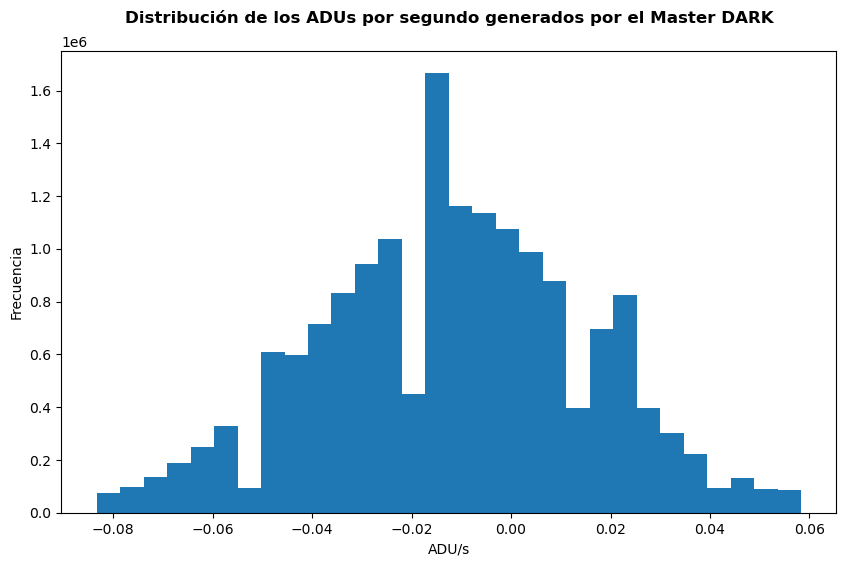

In [20]:
DARK = "DARK"
dark = os.listdir(DARK) #definiendo la carpeta donde se ubican los archivos DARK
datos_dark = []

for archivo in dark: #se explora la carpeta
    ruta = DARK + "/" + archivo #se define la ruta del archivo
    with fits.open(ruta) as hdul:
        data_dark = hdul[0].data #se extrae la información del archivo
        exptime_dark = hdul[0].header['EXPTIME'] #es importante conocer el tiempo de exposición, se extrae del header
        print("Tiempo de exposición de", ruta, ":", exptime_dark) #pedimos imprimir en pantalla el tiempo de exposición, para cada archivo
        dark_frames = (data_dark - master_bias) / exptime_dark #se calibran los 'dark frames', para obtener unicamente la contribucion por dark current
        datos_dark.append(dark_frames) #se agregan los datos normalizados por tiempo de exposición a la lista
        
datos_dark_array = np.array(datos_dark) 
master_dark = np.median(datos_dark_array, axis=0) #combinación de datos vía mediana

#Despliegue del histograma:

Min = np.min(datos_dark_array)
Max = np.max(datos_dark_array)
Mean = np.mean(datos_dark_array)
Stdev = np.std(datos_dark_array)
print(type(datos_dark_array.flatten()))
print(datos_dark_array.flatten().shape)
vmin = np.percentile(master_dark, 1)
vmax = np.percentile(master_dark, 99)
plt.figure(figsize=(10, 6))
histogram = plt.hist(master_dark.flatten(), bins=30, range = (vmin, vmax))
plt.title("Distribución de los ADUs por segundo generados por el Master DARK", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("ADU/s", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.show()

##### Surgió un problema, ya que en el histograma vemos que la gran mayoriá de ADUS/s generados son negativos, lo cual no tiene sentido. Hay que chequear que los datos de las imagenes tipo DARK estén correctamente tomadas. Se hace aún más evidente el problema cuando 'ploteamos' el promedio y desviación estándar:

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\benja\AppData\Local\Temp\ipykernel_13276\509798803.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(Mean - Stdev, color='green', linestyle='--', linewidth=2, label=f'$\sigma = {Stdev:.2f}$')


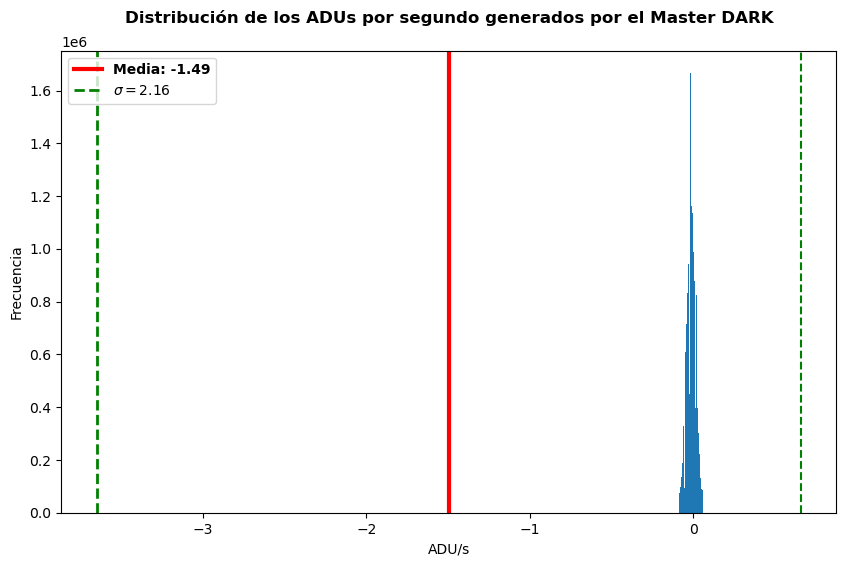

In [21]:
plt.figure(figsize=(10, 6))
histogram = plt.hist(master_dark.flatten(), bins=30, range = (vmin, vmax))
plt.title("Distribución de los ADUs por segundo generados por el Master DARK", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("ADU/s", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.axvline(Mean, color='red', linestyle='-', linewidth=3, label=f'Media: {Mean:.2f}')
plt.axvline(Mean - Stdev, color='green', linestyle='--', linewidth=2, label=f'$\sigma = {Stdev:.2f}$')
plt.axvline(Mean + Stdev, color='green', linestyle='--') #se agregan los demarcadores de la media y la desviación estándar
plt.legend(fontsize=12, prop={'weight':'bold'})
plt.show()

##### La media escapa totalmente de todo rango aceptable y la desviación estándar es altísima. Ahora sí, chequeamos:

In [22]:
for archivo in dark:
    ruta = DARK + "/" + archivo
    with fits.open(ruta) as hdul:
        data_dark = hdul[0].data
        exptime_dark = hdul[0].header['EXPTIME']
        image_type = hdul[0].header['IMAGETYP'] #además del tiempo de exposición, nos aseguramos de haber clasificado correctamente los archivos
        temp_ccd = hdul[0].header['CCD-TEMP'] #chequeamos la temperatura del CCD, que afecta directamente a la dark current. se extrae del header
        print("Archivo:", ruta)
        print("Tipo de imagen:", image_type)
        print("Tiempo de exposición de:", exptime_dark)
        print("Temperatura del CCD:",temp_ccd)

Archivo: DARK/image11.fit
Tipo de imagen: Dark Frame
Tiempo de exposición de: 240.0
Temperatura del CCD: -25.0
Archivo: DARK/image2.fit
Tipo de imagen: Dark Frame
Tiempo de exposición de: 200.0
Temperatura del CCD: -15.8
Archivo: DARK/image8.fit
Tipo de imagen: Dark Frame
Tiempo de exposición de: 180.0
Temperatura del CCD: -25.0


##### Acá podría estar el problema, ya que lo que hacemos al toamr la imagen dark es medir la "dark current" generada por la propia medición, si el CCD presenta una temperatura diferente al momento de la medición se obtendrá una corriente distinta. La 'image2.fit' es la que presenta una temperatura diferente al resto, mas alta que las otras 2. Por lo que voy a repetir el proceso pero excluyendo esta imagen que podría ser el problema.

##### Es más, al plotear un histograma con la distribución de ADUS/s generados por cada imagen por separado vemos como la 'image2.fit' presenta una distribución totalmenta anomala:

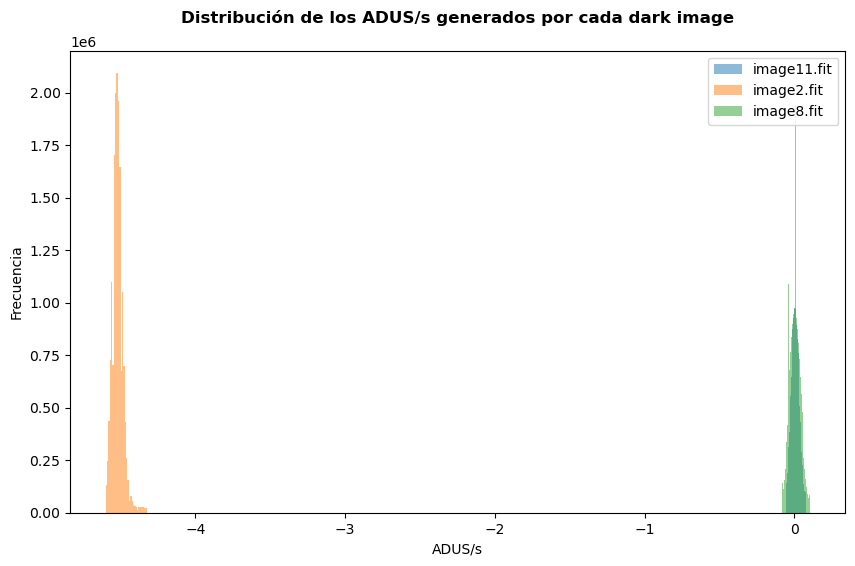

In [23]:
DARK = "DARK"
dark = os.listdir(DARK)
datos_dark = []

plt.figure(figsize=(10, 6))

for archivo in dark:
    ruta = DARK + "/" + archivo
    with fits.open(ruta) as hdul:
        data_dark = hdul[0].data
        exp_time = hdul[0].header['EXPTIME']
        dark_frames = (data_dark - master_bias) / exp_time
        datos_dark.append(dark_frames)
        vmin = np.percentile(dark_frames, 1) #se define el límite inferior y superior de los datos mediante el percentil más bajo y más alto
        vmax = np.percentile(dark_frames, 99)
        
    plt.hist(dark_frames.flatten(), bins=30, range=(vmin, vmax), alpha=0.5, label=archivo)
    #De esta manera veo la distribución de ADUs/segundo que aporta la 'dark current' de cada imagen individualmente

#Despliegue del histograma:

plt.title("Distribución de los ADUS/s generados por cada dark image", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("ADUS/s", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10, loc='upper right')
plt.show()

##### Es por esto que 'image2' queda totalmente descartada de la reducción. A continuación, replicamos el código anterior para calcular el Master DARK. Es importante mencionar que antes de sacar la mediana del set de imágenes 'dark' calibradas se debe "normalizar" cada imagen calibrada por su tiempo exposición, ya que la cantidad de 'dark current' depende de este tiempo de exposición:

<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
C:\Users\benja\AppData\Local\Temp\ipykernel_13276\194395705.py:37: SyntaxWarning: invalid escape sequence '\s'
  label=f'$\sigma = {Stdev:.2f}$')


Min: -0.2
Max: 356.5833333333333
Mean: 0.009170042516456724
Stdev: 0.29438746404523974
<class 'numpy.ndarray'>
(33554432,)


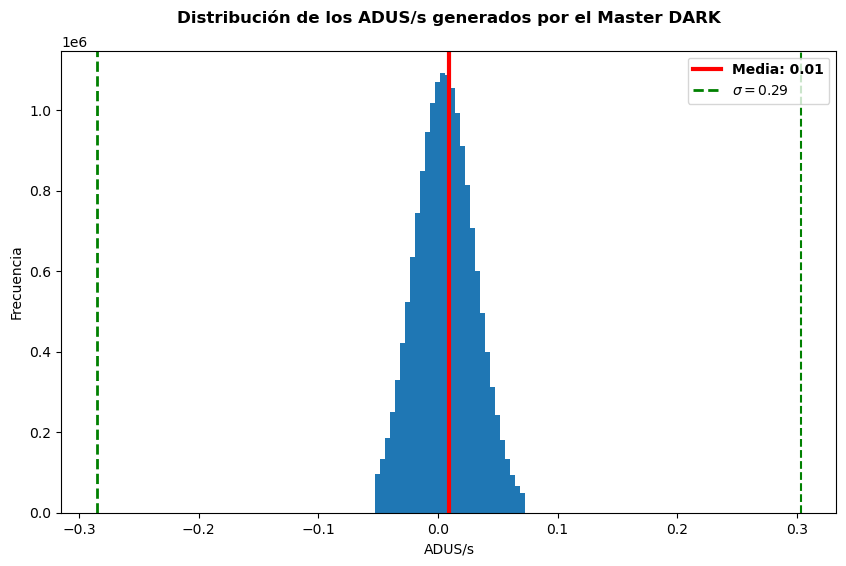

In [24]:
dark = ["image8.fit", "image11.fit"] #se cambia la ruta, creando una lista donde solo estén las imágenes que poseen una distribución coherente
datos_dark = []

for archivo in dark:
    ruta = DARK + "/" + archivo
    with fits.open(ruta) as hdul:
        data_dark = hdul[0].data
        exptime_dark = hdul[0].header['EXPTIME']
        dark_frames = (data_dark - master_bias) / exptime_dark
        datos_dark.append(dark_frames)
        
datos_dark_array = np.array(datos_dark)
master_dark = np.median(datos_dark_array, axis=0)

Min = np.min(datos_dark_array)
Max = np.max(datos_dark_array)
Mean = np.mean(datos_dark_array)
Stdev = np.std(datos_dark_array)
#mismo procedimiento que antes, unicamente cambia la carpeta de busqueda
print("Min:", Min)
print("Max:", Max)
print("Mean:", Mean)
print("Stdev:", Stdev)
print(type(datos_dark_array.flatten()))
print(datos_dark_array.flatten().shape)
vmin = np.percentile(master_dark, 1)
vmax = np.percentile(master_dark, 99)

#Despliegue de histograma:

plt.figure(figsize=(10, 6))
histogram = plt.hist(master_dark.flatten(), bins=30, range = (vmin, vmax))
plt.axvline(Mean, color='red', linestyle='-', linewidth=3, 
            label=f'Media: {Mean:.2f}')

plt.axvline(Mean - Stdev, color='green', linestyle='--', linewidth=2, 
            label=f'$\sigma = {Stdev:.2f}$')
plt.axvline(Mean + Stdev, color='green', linestyle='--')

plt.title("Distribución de los ADUS/s generados por el Master DARK", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("ADUS/s", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(fontsize=12, prop={'weight':'bold'})
plt.show()


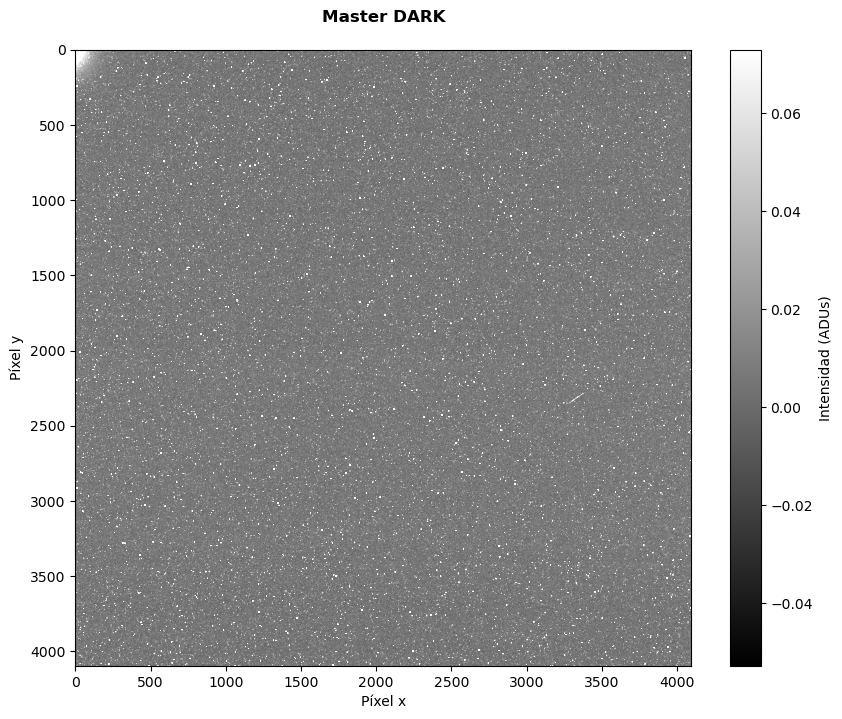

In [25]:
#Despliegue de la imagen del Master DARK

plt.figure(figsize=(10, 8))
plt.imshow(master_dark, cmap="grey", vmin=vmin, vmax=vmax)
plt.title("Master DARK", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("Píxel x", fontsize=10)
plt.ylabel("Píxel y", fontsize=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
cbar = plt.colorbar()
cbar.set_label("Intensidad (ADUs)", fontsize=10)
plt.show()

##### De la distribución que generamos del Master DARK podemos estimar que se generan en promedio aproximadamente 0.0092 [ADUs/segundo], es decir, cada segundo de observación agregará 0.0092 ADUs adicionales a la medición provenientes de la 'dark current'.

## MASTER FLAT

##### Ahora pasamos al último paso de la calibración antes de la reducción. Antes de la construcción del Master FLAT es importante verificar que las imágenes FLAT estén tomadas con el mismo filtro (para captar la misma cantidad de ruido por polvo), tiempo de exposición (por sensibilidad de los píxeles) y temperatura del CDD:

In [26]:
os.listdir("FLAT")

['image14.fit', 'image17.fit', 'image19.fit', 'image3.fit']

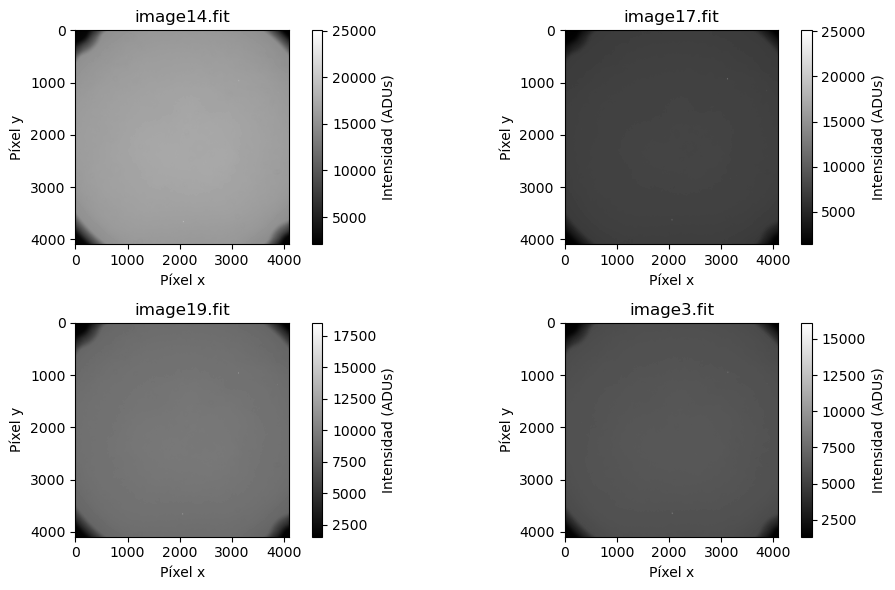

In [27]:
flat_images = ['FLAT/image14.fit', 'FLAT/image17.fit', 'FLAT/image19.fit', 'FLAT/image3.fit'] #ruta de busqueda
plt.figure(figsize=(10, 6))
for i, imagen in enumerate(flat_images):
    plt.subplot(2, 2, i + 1) #queremos visualizar una a una las imágenes de forma ordenada
    with fits.open(imagen) as hdul:
        data_flat = hdul[0].data #se extrae la información de cada archivo
        plt.imshow(data_flat, cmap="gray") #se muestra la imagen cruda
        plt.title(imagen.split('/')[-1])
        plt.xlabel("Píxel x", fontsize=10)
        plt.ylabel("Píxel y", fontsize=10)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        cbar = plt.colorbar()
        cbar.set_label("Intensidad (ADUs)", fontsize=10)
plt.tight_layout()
plt.show()

##### Al observar las imágenes 'flat' vemos que el instrumento usado tiene los bordes "oscurecidos" (probablemente proviene del filtro utilizado), además del polvo observado en forma de "dona" en todo el lente, en la siguiente parte del código vemos las condiciones en las que fueron tomadas las imágenes:

In [28]:
flat_images = ['FLAT/image14.fit', 'FLAT/image17.fit', 'FLAT/image19.fit', 'FLAT/image3.fit']

for imagen in flat_images: #exploramos cada archivo en la carpeta
    with fits.open(imagen) as hdul:
        data_flat = hdul[0].data  #extraemos la información
        vmin = np.min(data_flat)
        vmax = np.max(data_flat)
        filtro = hdul[0].header['FILTER'] #extraemos el filtro utilizado, usando el header
        tiempo_de_exposición = hdul[0].header['EXPTIME'] #extraemos del header el tiempo de exposición
        temperatura = hdul[0].header['CCD-TEMP'] #además también la temperatura del CCD
        print("Imagen =", imagen)
        print("Filtro =", filtro)
        print("Tiempo de exposición =",tiempo_de_exposición)
        print("Temperatura del CCD =", temperatura)

Imagen = FLAT/image14.fit
Filtro = sloan_r
Tiempo de exposición = 5.0
Temperatura del CCD = -26.0
Imagen = FLAT/image17.fit
Filtro = sloan_r
Tiempo de exposición = 10.0
Temperatura del CCD = -26.0
Imagen = FLAT/image19.fit
Filtro = sloan_r
Tiempo de exposición = 5.0
Temperatura del CCD = -26.0
Imagen = FLAT/image3.fit
Filtro = sloan_r
Tiempo de exposición = 5.0
Temperatura del CCD = -26.0


##### Todas están tomadas bajo el filtro "sloan_r" y misma temperatura del CCD, por lo que por ese lado no hay problemas. Sin embargo, la 'image17.fit' presenta el doble de tiempo de exposición que las demás. Es por esto que las imágenes FLAT tienen que ser normalizadas, ya que la sensibilidad de los píxeles puede añadir ADUs dependiendo del tiempo de exposición, por lo que en la construcción del Master FLAT se hace una "doble normalización". Veamos la distribución de ADUs de cada 'flat':

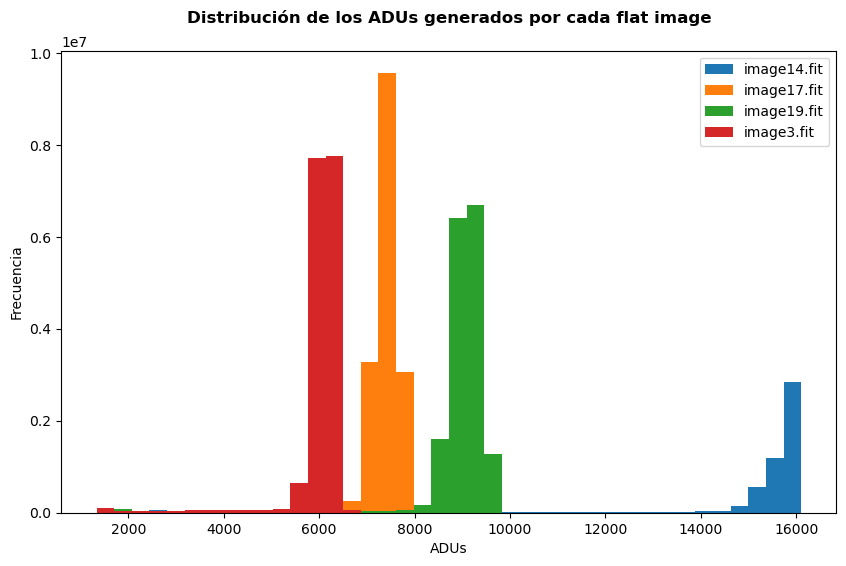

In [29]:
plt.figure(figsize=(10, 6))

FLAT = "FLAT"
flat = os.listdir(FLAT) #se define la carpeta con los archivos

for archivo in flat: #se recorren los archivos uno a uno
    ruta = FLAT + "/" + archivo #se define una ruta para cada archivo
    with fits.open(ruta) as hdul:
        flat_i = hdul[0].data #se extrae la data de cada archivo
        histogram = plt.hist(flat_i.flatten(), label=archivo, bins=40, range = (vmin, vmax)) #generamos un histograma de la distribución de ADUs de cada imagen

#Despliegue de gráficas:
plt.title("Distribución de los ADUs generados por cada flat image", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("ADUs", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10, loc='upper right')
plt.show()

##### Aquí se aprecia como todos los 'flats' generan una distribución distinta de ADUs, producto de la intensidad del brillo del cielo al momento de ser capturadas, por lo que para calibrar la reducción y poder armar un 'Master FLAT' las distribuciones deben estar centradas, normalizadas. Queremos eliminar la dependencia de la intensidad del brillo en el cielo, la ganancia del CCD y el tiempo de exposición.

In [30]:
FLAT = "FLAT"
flat = os.listdir(FLAT) #se define la carpeta donde están los archivos FLAT
datos_flat = []

for archivo in flat: #se explora cada archivo
    ruta = FLAT + "/" + archivo #se define la ruta de cada archivo
    with fits.open(ruta) as hdul:
        flat_i = hdul[0].data #se extrae la data de cada archivo
        exptime = hdul[0].header['EXPTIME'] #se extrae del header el tiempo de exposición
        num = (flat_i - master_bias - master_dark*exptime) # se elimina de los archivos flat la "contaminación" por dark current y read-out noise
        mediana = np.median(num) #se extrae la mediana de los datos de la imagen "limpia"
        flat_frames = num/mediana #Primera normalización de los datos
        datos_flat.append(flat_frames)

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
C:\Users\benja\AppData\Local\Temp\ipykernel_13276\155684006.py:17: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(Mean - Stdev, color='green', linestyle='--', linewidth=2, label=f'$\sigma = {Stdev:.2f}$')


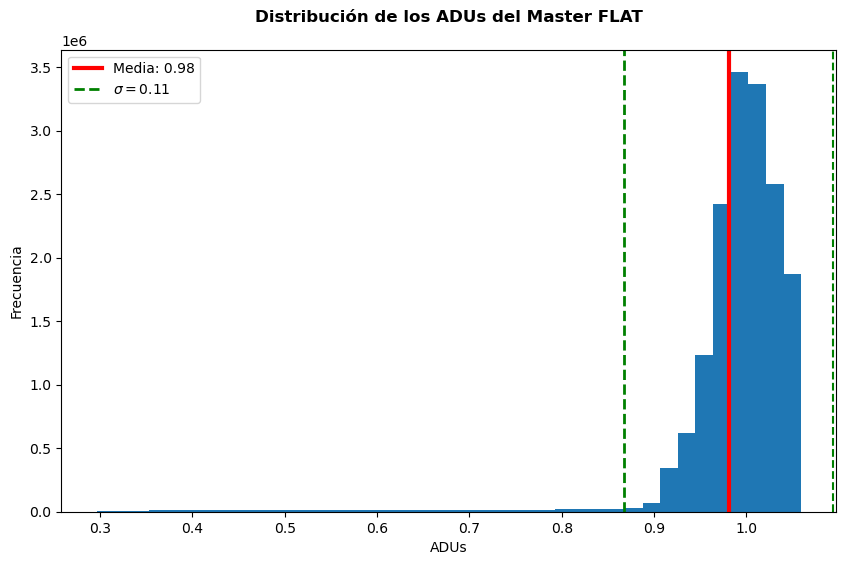

In [31]:
datos_flat_array = np.array(datos_flat)
master_flat = np.median(datos_flat_array, axis=0) #segunda normalización
vmin = np.percentile(master_flat, 1)
vmax = np.percentile(master_flat, 99) #se definen los limites por percentiles

#visualización de la distribución de datos del Master FLAT
plt.figure(figsize=(10, 6))
histogram = plt.hist(master_flat.flatten(), bins=40, range = (vmin, vmax))
plt.title("Distribución de los ADUs del Master FLAT", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("ADUs", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
Min = np.min(datos_flat_array)
Max = np.max(datos_flat_array)
Mean = np.mean(datos_flat_array)
Stdev = np.std(datos_flat_array)
plt.axvline(Mean, color='red', linestyle='-', linewidth=3, label=f'Media: {Mean:.2f}')
plt.axvline(Mean - Stdev, color='green', linestyle='--', linewidth=2, label=f'$\sigma = {Stdev:.2f}$')
plt.axvline(Mean + Stdev, color='green', linestyle='--')
plt.legend(fontsize=10, loc='upper left')
plt.show()

##### Luego de la doble normalización, observamos que la intensidad de ADUs de cada 'flat frame' se centran en 1, siguiendo una distribución estándar. Esto permite combinar estadísticamente la información de cada 'flat frame' sin que el resultado se vea sesgado por las diferencias en la luz captada. En la reducción final, el Master FLAT permite normalizar la imagen corrigiendo cualquier exceso de intensidad en los píxeles producto de la sensibilidad de cada uno al momento de la observación.

## REDUCTION AND SCIENCE IMAGE

##### Finalmente, luego de todas las correcciones hechas al instrumento, se procede a la reducción de imagen, que consiste en tomar las imágenes 'Light' (las observaciones en sí) y quitarle todos los ADUs añadidos por error. Esto es, utilizar cada Master Image que se construyó para calibrar la reducción y obtener una imagen limpia, sin read-out noise, dark current ni polvo o sensibilidad del telescopio. Vamos a seleccionar una imagen cualquiera de la carpeta 'LIGHT':

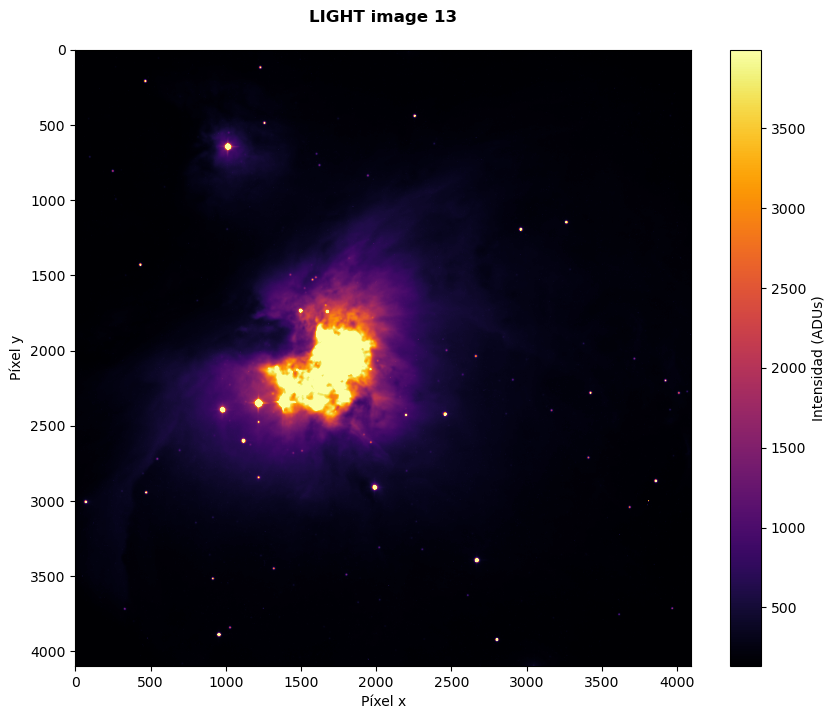

In [32]:
os.listdir("LIGHT") #se selecciona la carpeta con las imágenes tipo LIGHT
imagen = ['LIGHT/image13.fit'] #se selecciona una de las imágenes al azar
for archivo in imagen:
    with fits.open(archivo) as hdul:
        data_imagen = hdul[0].data #se extrae la información
        vmin = np.percentile(data_imagen, 5) #se establecen los límites para visualizar la imagen en un rango apropiado de ADUs
        vmax = np.percentile(data_imagen, 99) #la idea de utilizar los percentiles es evitar que datos alejados de la distribución perturben la imagen

#Se despliega la imagen:

plt.figure(figsize=(10, 8))
plt.imshow(data_imagen, cmap="inferno", vmin = vmin, vmax = vmax)
plt.title("LIGHT image 13", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("Píxel x", fontsize=10)
plt.ylabel("Píxel y", fontsize=10)
cbar = plt.colorbar()
cbar.set_label("Intensidad (ADUs)", fontsize=10)
plt.show()

##### Se puede apreciar que la imagen posee saturación en el objeto de interés y además mucho polvo alrededor, a continuación se aplica la corrección utilizando las calibraciones anteriores:

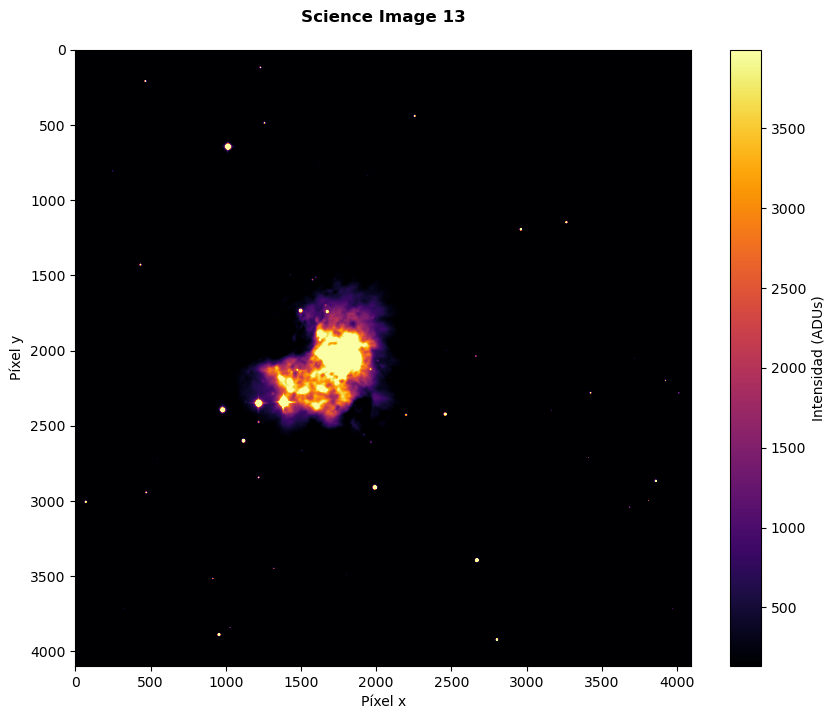

In [33]:
imagen = ['LIGHT/image13.fit'] #se selecciona la carpeta con las imágenes LIGHT
for archivo in imagen:
    with fits.open(archivo) as hdul:
        data_imagen = hdul[0].data #Se extrae su información
        exp_time = hdul[0].header['EXPTIME'] #extraemos del header su tiempo de exposición
        imagen_corregida = (data_imagen - master_bias - master_dark*exp_time)/master_flat #Se aplica la reducción con todas las calibraciones anteriores
        #Se incluye la corrección del 'read-out noise' con el Master BIAS, de la 'dark current' con el Master DARK normalizado por el tiempo
        #de exposición y del polvo y sensibilidad de los píxeles con el Master FLAT.

#Despliegue de la imagen reducida:

plt.figure(figsize=(10, 8))
plt.imshow(imagen_corregida, cmap="inferno", vmin = vmin, vmax = vmax)
plt.title("Science Image 13", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("Píxel x", fontsize=10)
plt.ylabel("Píxel y", fontsize=10)
cbar = plt.colorbar()
cbar.set_label("Intensidad (ADUs)", fontsize=10)
plt.show()

##### Siendo este el resultado final, una imagen con menos saturación, menos contaminación en los alrededores y con el objeto central más visible. Si vemos el residuo entre ambas imágenes podemos ver principalmente lo que fue "extraído" en la reducción, todo el ruido producto de los errores base que nos encargamos de quitar en la cosntrucción de las Master Images.

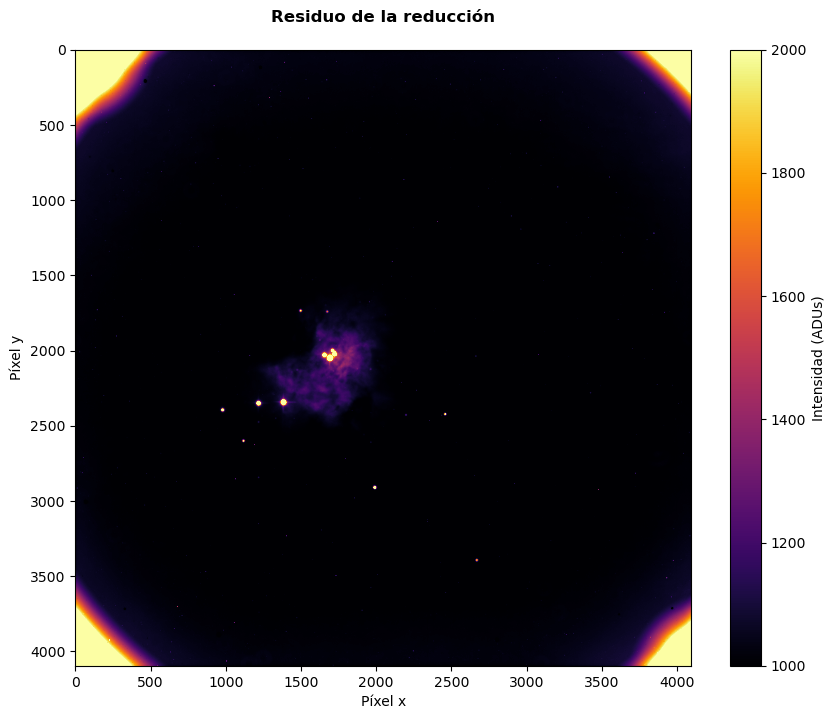

In [34]:
residual = data_imagen - imagen_corregida #se define el residuo como los ADUs restantes que quita la corrección

#Despliegue de la imagen residual:

plt.figure(figsize=(10, 8))
plt.imshow(residual, cmap="inferno", vmin = 1000, vmax = 2000)
plt.title("Residuo de la reducción", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("Píxel x", fontsize=10)
plt.ylabel("Píxel y", fontsize=10)
cbar = plt.colorbar()
cbar.set_label("Intensidad (ADUs)", fontsize=10)
plt.show()

##### En la imagen residual vemos el 'efecto viñeta' que producen los filtros de los flat frames, que fueron removidos en la reducción, además de varias estrellas que producían un exceso de brillo, esto también fue corregido gracias al Master FLAT y su normalización de la sensibilidad. en los alrededores del objeto se pueden observar algunos píxeles removidos probablemente provenientes de los Master BIAS y DARK.

##### En base a las imagenes obtenidas se puede concluir que estamos en presencia de una nebulosa, debido a la cantidad de polvo y gas que la reducción extrajo. Podemos observar presencia de lo que parecen ser estrellas detrás de la nebulosa, indicando que esta es una zona de formación estelar activa, probablemente una región de HII. Podemos desplegar el header y extraer la siguiente información:

In [51]:
with fits.open('LIGHT/image13.fit') as hdul:
    hdul.info();
    objeto = hdul[0].header['OBJECT']

print('Objeto:', objeto)

Filename: LIGHT/image13.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      49   (4096, 4096)   int16 (rescales to uint16)   
Objeto: NGC 1976


##### Estamos observando a 'NGC 1976' o mejor conocida como la Nebulosa de Orión. Introduciendo su identificador en 'Aladin Sky Atlas' podemos ver que efectivamente se trata de la nebulosa, la cual es una región HII de formación estelar activa y obtener esta hermosa postal:

<div align="center">
  <img src="M42.png" width="1000px">
  <p><i>Nebulosa de Orión.</i></p>
</div>

In [56]:
with fits.open('LIGHT/image13.fit') as hdul:
    hdul.info();
    header = hdul[0].header

header

Filename: LIGHT/image13.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      49   (4096, 4096)   int16 (rescales to uint16)   


SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 4096 / length of data axis 1                          
NAXIS2  =                 4096 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
OBSERVER= 'USM     '           / SBIGFITSEXT The name of the observer           
ORIGIN  = 'MAS500  '           / Description of location                        
TELESCOP= 'MAS500  '        

##### El header nos entrega información adicional de la observación de M42, la resolución fue de 4096x4096 píxeles, el filtro sloan_r observa en la banda roja del rango visible del espectro electromagnético. La observación debe haberse hecho con este filtro ya que las regiones HII como la Nebulosa de Orión poseen fuerte emisión en esta parte del espectro producto de la formación estelar, especialmente la línea de $H_\alpha$, que es vital para la detección de estas regiones.